# Starbucks Customer Churn Prediction for Customer Retention using Machine Learning

## Objective

Customer retention is a critical business objective, as retaining existing customers is generally more cost-effective than acquiring new ones. This project aims to develop a machine learning model that identifies customers at risk of churning based on their purchasing behavior and engagement patterns.

Since the dataset does not contain an explicit churn label, churn is defined using a business rule based on customer inactivity.

In [3]:
# Import the required libraries for data manipulation, visualization,
# feature engineering, and machine learning.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load the Starbucks customer ordering dataset into a pandas DataFrame.
data = pd.read_csv("starbucks_customer_ordering_patterns.csv")

In [5]:
# Examine the dataset structure, data types, and identify missing values.
data.head()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   order_id               100000 non-null  object 
 2   order_date             100000 non-null  object 
 3   order_time             100000 non-null  object 
 4   day_of_week            100000 non-null  object 
 5   order_channel          100000 non-null  object 
 6   store_id               100000 non-null  object 
 7   store_location_type    100000 non-null  object 
 8   region                 100000 non-null  object 
 9   customer_age_group     100000 non-null  object 
 10  customer_gender        100000 non-null  object 
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend            100000 non-nul

In [7]:
# Convert date columns into datetime format to support time-based analysis.
data["order_date"] = pd.to_datetime(data["order_date"])
data["order_time"] = pd.to_datetime(data["order_time"]).dt.hour

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            100000 non-null  object        
 1   order_id               100000 non-null  object        
 2   order_date             100000 non-null  datetime64[ns]
 3   order_time             100000 non-null  int32         
 4   day_of_week            100000 non-null  object        
 5   order_channel          100000 non-null  object        
 6   store_id               100000 non-null  object        
 7   store_location_type    100000 non-null  object        
 8   region                 100000 non-null  object        
 9   customer_age_group     100000 non-null  object        
 10  customer_gender        100000 non-null  object        
 11  is_rewards_member      100000 non-null  bool          
 12  cart_size              100000 non-null  int64

In [9]:
# creating date reference max date + 1 day
reference_date = data["order_date"].max() + dt.timedelta(days = 1)
reference_date

Timestamp('2025-12-31 00:00:00')

In [10]:
# Examine the numerical data descriptive statistic
data.select_dtypes(include =["int","float"]).describe()

,order_time,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,11.763660,3.741510,1.81077,14.866771,4.546080,3.687530
std,4.596611,1.697817,1.46280,5.506800,1.550269,1.184123
min,0.000000,1.000000,0.00000,3.510000,1.000000,1.000000
25%,8.000000,3.000000,1.00000,10.837500,3.400000,3.000000
50%,12.000000,4.000000,2.00000,14.170000,4.400000,4.000000
75%,16.000000,5.000000,3.00000,18.180000,5.500000,5.000000
max,23.000000,10.000000,8.00000,40.310000,11.200000,5.000000


In [11]:
data.columns

Index(['customer_id', 'order_id', 'order_date', 'order_time', 'day_of_week',
       'order_channel', 'store_id', 'store_location_type', 'region',
       'customer_age_group', 'customer_gender', 'is_rewards_member',
       'cart_size', 'num_customizations', 'total_spend',
       'fulfillment_time_min', 'drink_category', 'has_food_item',
       'order_ahead', 'customer_satisfaction'],
      dtype='object')

In [12]:
# Aggregate transactional data to create one record per customer
# for customer-level churn analysis.

churn_df = data.groupby("customer_id").agg({
    "order_id" : "count",
    "order_date" : lambda x : (reference_date - x.max()).days,
    "order_time" : "mean",
    "day_of_week": lambda x : x.mode()[0],
    "order_channel": lambda x :x.mode()[0],
    "store_location_type": lambda x: x.mode()[0],
    "region": lambda x : x.mode()[0],
    "customer_age_group": lambda x : x.mode()[0],
    "customer_gender": lambda x : x.mode()[0],
    "is_rewards_member": lambda x : x.mode()[0],
    "cart_size" : "mean",
    "num_customizations" : "mean",
    "total_spend" : "mean",
    "fulfillment_time_min" : "mean",
    "drink_category" : lambda x : x.mode()[0],
    "has_food_item" : lambda x : x.mode()[0],
    "order_ahead" : lambda x: x.mode()[0],
    "customer_satisfaction" : "mean",




})

In [13]:
churn_df

,order_id,order_date,order_time,day_of_week,order_channel,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
customer_id,,,,,,,,,,,,,,,,,,
CUST_00001,12,41,11.083333,Sun,Drive-Thru,Suburban,Midwest,35-44,Male,False,3.666667,2.500000,14.550000,5.133333,Brewed Coffee,False,False,3.250000
CUST_00002,13,62,14.384615,Thu,Mobile App,Urban,Southwest,25-34,Male,False,4.076923,2.076923,15.936923,4.461538,Refresher,False,False,4.076923
CUST_00003,5,84,14.200000,Tue,Mobile App,Suburban,Midwest,35-44,Female,False,4.200000,1.200000,15.942000,4.940000,Espresso,False,False,3.400000
CUST_00004,7,146,11.142857,Tue,Drive-Thru,Suburban,Southwest,45-54,Male,False,3.571429,2.000000,13.692857,4.742857,Other,False,False,4.142857
CUST_00005,3,80,6.333333,Tue,Drive-Thru,Suburban,Midwest,25-34,Male,False,4.666667,1.333333,15.816667,4.733333,Espresso,False,False,3.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CUST_14996,6,43,10.666667,Sat,Mobile App,Suburban,Southwest,25-34,Female,False,4.000000,2.166667,15.526667,4.516667,Frappuccino,False,False,4.000000
CUST_14997,9,1,15.222222,Fri,Mobile App,Suburban,Southeast,25-34,Male,True,3.777778,2.333333,16.154444,4.733333,Refresher,False,True,3.111111
CUST_14998,5,35,11.000000,Fri,Drive-Thru,Rural,West,55+,Male,False,3.400000,1.600000,12.974000,4.680000,Brewed Coffee,True,False,3.400000


In [14]:
# renaming the columns
churn_df.rename(columns={"order_id":"num_of_orders",
                         "order_date": "days_from_last_order"}, inplace =True)

In [15]:
churn_df.head()

,num_of_orders,days_from_last_order,order_time,day_of_week,order_channel,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
customer_id,,,,,,,,,,,,,,,,,,
CUST_00001,12,41,11.083333,Sun,Drive-Thru,Suburban,Midwest,35-44,Male,False,3.666667,2.500000,14.550000,5.133333,Brewed Coffee,False,False,3.250000
CUST_00002,13,62,14.384615,Thu,Mobile App,Urban,Southwest,25-34,Male,False,4.076923,2.076923,15.936923,4.461538,Refresher,False,False,4.076923
CUST_00003,5,84,14.200000,Tue,Mobile App,Suburban,Midwest,35-44,Female,False,4.200000,1.200000,15.942000,4.940000,Espresso,False,False,3.400000
CUST_00004,7,146,11.142857,Tue,Drive-Thru,Suburban,Southwest,45-54,Male,False,3.571429,2.000000,13.692857,4.742857,Other,False,False,4.142857
CUST_00005,3,80,6.333333,Tue,Drive-Thru,Suburban,Midwest,25-34,Male,False,4.666667,1.333333,15.816667,4.733333,Espresso,False,False,3.666667


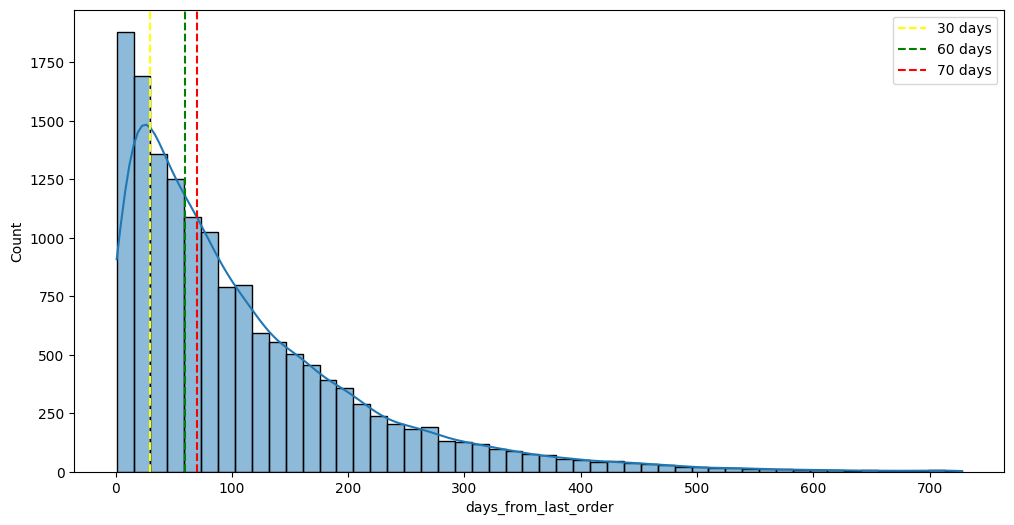

In [16]:
# Engineer customer behavioral features from historical transactions.
plt.figure(figsize=(12,6))
sns.histplot(churn_df["days_from_last_order"], bins = 50, kde= True)
plt.axvline(30, color = "yellow", label = "30 days", linestyle = "--")
plt.axvline(60, color = "green", label = "60 days", linestyle  = "--")
plt.axvline(70, color = "red", label = "70 days", linestyle = "--")
plt.legend()
plt.show()

In [17]:
# Create the churn target variable using customer inactivity.
# Customers inactive for more than 70 days are classified as churned.

churn_df["churn"] = churn_df["days_from_last_order"].apply(lambda x: 1 if x > 70 else 0)

In [18]:
churn_df

,num_of_orders,days_from_last_order,order_time,day_of_week,order_channel,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction,churn
customer_id,,,,,,,,,,,,,,,,,,,
CUST_00001,12,41,11.083333,Sun,Drive-Thru,Suburban,Midwest,35-44,Male,False,3.666667,2.500000,14.550000,5.133333,Brewed Coffee,False,False,3.250000,0
CUST_00002,13,62,14.384615,Thu,Mobile App,Urban,Southwest,25-34,Male,False,4.076923,2.076923,15.936923,4.461538,Refresher,False,False,4.076923,0
CUST_00003,5,84,14.200000,Tue,Mobile App,Suburban,Midwest,35-44,Female,False,4.200000,1.200000,15.942000,4.940000,Espresso,False,False,3.400000,1
CUST_00004,7,146,11.142857,Tue,Drive-Thru,Suburban,Southwest,45-54,Male,False,3.571429,2.000000,13.692857,4.742857,Other,False,False,4.142857,1
CUST_00005,3,80,6.333333,Tue,Drive-Thru,Suburban,Midwest,25-34,Male,False,4.666667,1.333333,15.816667,4.733333,Espresso,False,False,3.666667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CUST_14996,6,43,10.666667,Sat,Mobile App,Suburban,Southwest,25-34,Female,False,4.000000,2.166667,15.526667,4.516667,Frappuccino,False,False,4.000000,0
CUST_14997,9,1,15.222222,Fri,Mobile App,Suburban,Southeast,25-34,Male,True,3.777778,2.333333,16.154444,4.733333,Refresher,False,True,3.111111,0
CUST_14998,5,35,11.000000,Fri,Drive-Thru,Rural,West,55+,Male,False,3.400000,1.600000,12.974000,4.680000,Brewed Coffee,True,False,3.400000,0


In [19]:
# checking class balance
churn_df["churn"].value_counts(normalize= True)*100

,proportion
churn,
1,52.949026
0,47.050974


In [20]:
churn_df.shape

(14988, 19)

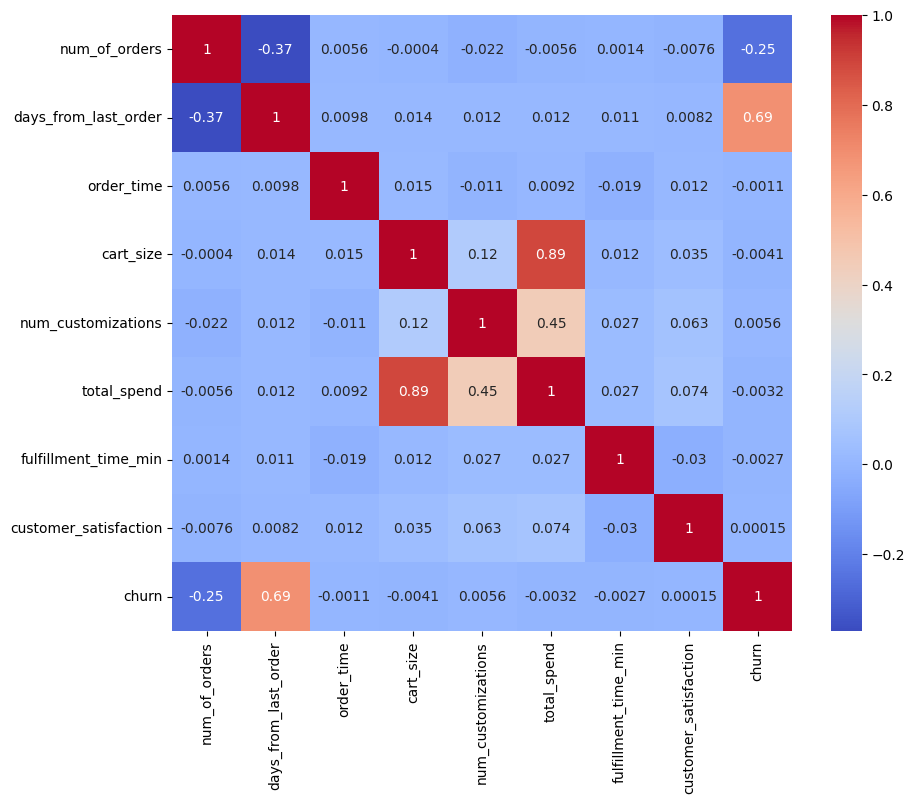

In [21]:
# checking for correlation among the numberical values

corr = churn_df.select_dtypes(include=["int", "float"]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.show()

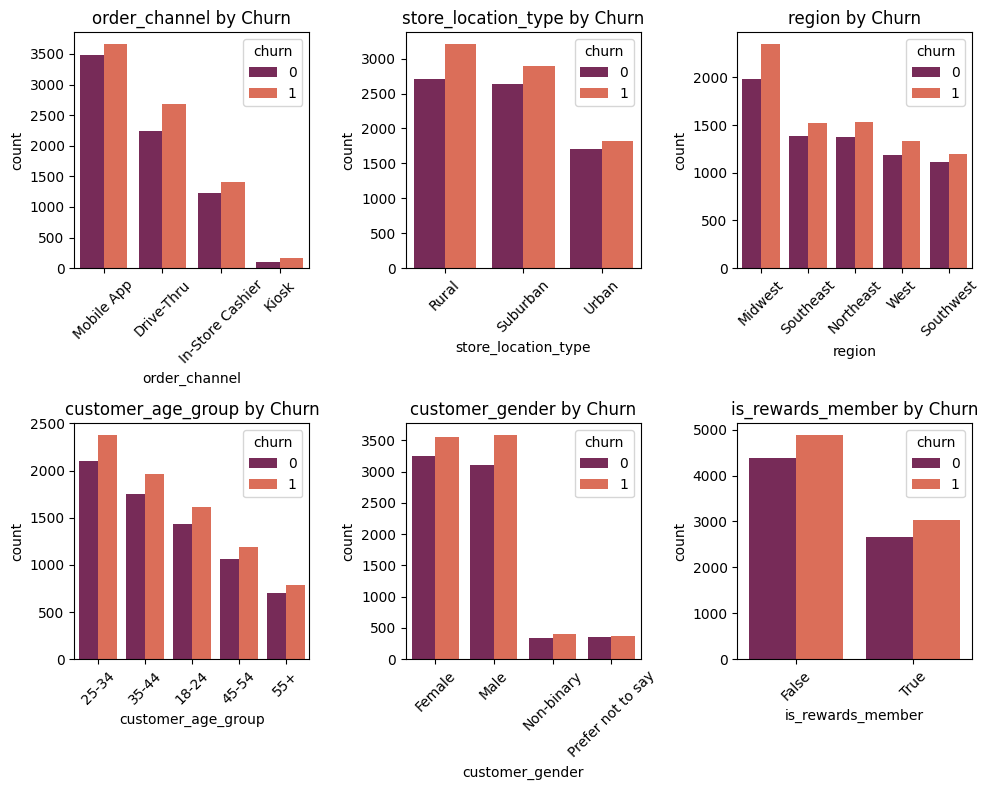

In [22]:
# Explore customer behavior and identify patterns associated with churn.

plot_df = ["order_channel", "store_location_type","region","customer_age_group",
           "customer_gender","is_rewards_member"]
plt.figure(figsize=(10,8))
for i, col in enumerate(plot_df):
  plt.subplot(2,3,1+i)
  sns.countplot(data = churn_df, x = col,
                hue = "churn", palette= "rocket",
                order = churn_df[col].value_counts().index)
  plt.title(f"{col} by Churn")
  plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()



In [23]:
# Convert categorical variables into numerical representations
# suitable for machine learning algorithms.

cat_col = churn_df.select_dtypes(include=["object","bool"]).columns

dummy = pd.get_dummies(churn_df[cat_col], drop_first= True, dtype= int)
dummy.head()

,is_rewards_member,has_food_item,order_ahead,day_of_week_Mon,day_of_week_Sat,day_of_week_Sun,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed,order_channel_In-Store Cashier,...,customer_age_group_45-54,customer_age_group_55+,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea
customer_id,,,,,,,,,,,,,,,,,,,,,
CUST_00001,False,False,False,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
CUST_00002,False,False,False,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
CUST_00003,False,False,False,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
CUST_00004,False,False,False,0,0,0,0,1,0,0,...,1,0,1,0,0,0,0,1,0,0
CUST_00005,False,False,False,0,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,0


In [24]:
churn_df = pd.concat([churn_df.drop(columns=cat_col), dummy], axis=1)
churn_df.head()

,num_of_orders,days_from_last_order,order_time,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction,churn,is_rewards_member,...,customer_age_group_45-54,customer_age_group_55+,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea
customer_id,,,,,,,,,,,,,,,,,,,,,
CUST_00001,12,41,11.083333,3.666667,2.500000,14.550000,5.133333,3.250000,0,False,...,0,0,1,0,0,0,0,0,0,0
CUST_00002,13,62,14.384615,4.076923,2.076923,15.936923,4.461538,4.076923,0,False,...,0,0,1,0,0,0,0,0,1,0
CUST_00003,5,84,14.200000,4.200000,1.200000,15.942000,4.940000,3.400000,1,False,...,0,0,0,0,0,1,0,0,0,0
CUST_00004,7,146,11.142857,3.571429,2.000000,13.692857,4.742857,4.142857,1,False,...,1,0,1,0,0,0,0,1,0,0
CUST_00005,3,80,6.333333,4.666667,1.333333,15.816667,4.733333,3.666667,1,False,...,0,0,1,0,0,1,0,0,0,0


In [25]:
# separating the predictor features (x) and target variable (y)
# droping churn, days_from_last_order and cart_size columns

x = churn_df.drop(columns=["churn","days_from_last_order","cart_size"]).reset_index(drop=True)
y = churn_df["churn"].reset_index(drop=True)

In [26]:
x.head()

,num_of_orders,order_time,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction,is_rewards_member,has_food_item,order_ahead,day_of_week_Mon,...,customer_age_group_45-54,customer_age_group_55+,customer_gender_Male,customer_gender_Non-binary,customer_gender_Prefer not to say,drink_category_Espresso,drink_category_Frappuccino,drink_category_Other,drink_category_Refresher,drink_category_Tea
0,12,11.083333,2.500000,14.550000,5.133333,3.250000,False,False,False,0,...,0,0,1,0,0,0,0,0,0,0
1,13,14.384615,2.076923,15.936923,4.461538,4.076923,False,False,False,0,...,0,0,1,0,0,0,0,0,1,0
2,5,14.200000,1.200000,15.942000,4.940000,3.400000,False,False,False,0,...,0,0,0,0,0,1,0,0,0,0
3,7,11.142857,2.000000,13.692857,4.742857,4.142857,False,False,False,0,...,1,0,1,0,0,0,0,1,0,0
4,3,6.333333,1.333333,15.816667,4.733333,3.666667,False,False,False,0,...,0,0,1,0,0,1,0,0,0,0


In [27]:
x.shape, y.shape

((14988, 36), (14988,))

In [28]:
# Split the dataset into training and testing subsets

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.20,
                                                    random_state=42,
                                                    )

In [29]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((11990, 36), (11990,), (2998, 36), (2998,))

In [30]:
# building and training the model
xg = CatBoostClassifier(verbose=False)
xg.fit(x_train, y_train)



CatBoostClassifier(verbose=False)

In [31]:
# predicting the y test
y_pred = xg.predict(x_test)

### Evaluate model performance using accuracy confusion matrix, and classification metrics.

In [32]:
# model accuracy
accuracy_score(y_test, y_pred)

0.5957304869913276

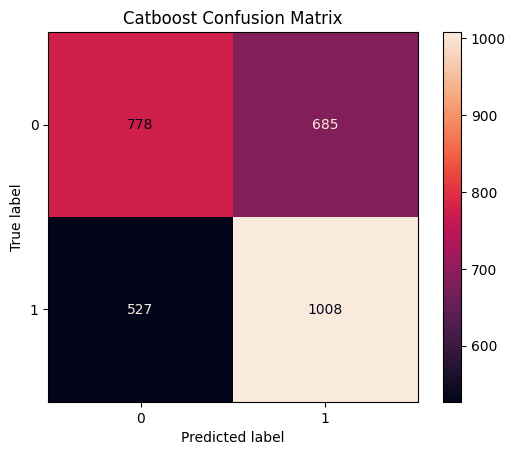

In [33]:
# plotting the confusion matrix
confusion = confusion_matrix(y_test, y_pred)
fig = ConfusionMatrixDisplay(confusion, display_labels = xg.classes_)
fig.plot(cmap = "rocket")
plt.title("Catboost Confusion Matrix")
plt.show()

In [34]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.53      0.56      1463
           1       0.60      0.66      0.62      1535

    accuracy                           0.60      2998
   macro avg       0.60      0.59      0.59      2998
weighted avg       0.60      0.60      0.59      2998



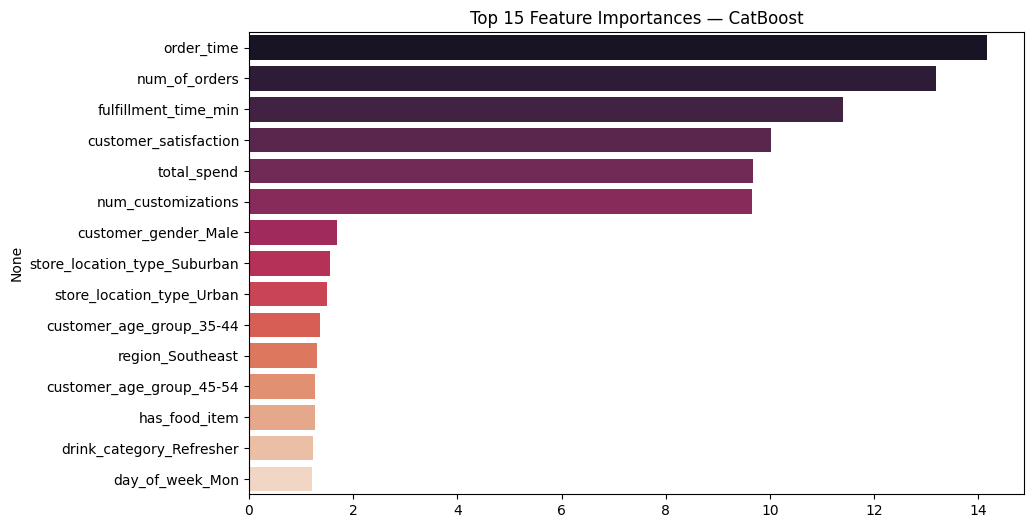

In [35]:
importances = pd.Series(xg.feature_importances_, index=x.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette="rocket")
plt.title("Top 15 Feature Importances — CatBoost")
plt.show()

# Conclusion

This project demonstrates a practical customer churn prediction workflow using customer ordering behavior and machine learning.

Since the original dataset did not contain an explicit churn label, a business-driven definition based on customer inactivity was developed to simulate a real-world retention scenario. Customer-level behavioral features were engineered from transactional data, allowing the CatBoost Classifier to learn meaningful patterns associated with customer churn.

The final model achieved an overall accuracy of **60%**. While the model does not perfectly classify every customer, it provides a realistic foundation for identifying customers who may require proactive retention efforts. The feature importance analysis further highlights the behavioral factors most strongly associated with churn, enabling businesses to prioritize retention campaigns more effectively.

This project demonstrates how customer analytics and machine learning can support data-driven marketing strategies by helping organizations reduce customer attrition, improve customer engagement, and optimize long-term customer value.
